# Dot Generation — Semifreddo + Ledidi (single example)

Optimises two bins separated by a desired distance (indices 231, 281 (with 50 bin inter-anchor distance) in the 512-bin map) of a flat genomic region to produce a strong dot.

**Key difference from full-sequence optimisation:** only the 11-bin padded sequence
slice around the edited bin is passed through the convolutional tower on each step;
all other activations are served from the pre-cached tower output.

```
editable bin #1 (in map) : 256-half_distance → 231
editable bin #2 (in map) : 256+half_distance → 281
sequence window #1     : bin 226–236 → 11 bins = 22 528 bp
sequence window #2     : bin 276–286 → 11 bins = 22 528 bp
```


## 1. Imports

In [1]:
import os
import sys

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
sys.path.insert(0, "/home1/smaruj/ledidi/ledidi/")
sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import TwoAnchorSemifreddoLedidiWrapper
from utils.data_utils import from_upper_triu
from utils.losses_utils import LocalL1Loss

## 2. Parameters

In [2]:
# ── Sequence to optimise ─────────────────────────────────────────────────
FOLD  = 0
CHROM = "chr3"
START = 38438912
END   = 39749632
STEM  = f"{CHROM}_{START}_{END}"

# ── Dot design parameters ─────────────────────────────────────────────────
DISTANCE = 50   # inter-anchor distance in bins

SEQ_BASE_DIR   = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/flat_regions"
TARGET_DIR = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/dots"
MASK_DIR     = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/feature_masks"
MODEL_PATH = ("/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/"
              "Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth")

SEQ_PATH    = f"{SEQ_BASE_DIR}/mouse_sequences/fold{FOLD}/{STEM}_X.pt"
TOWER_PATH  = f"{SEQ_BASE_DIR}/mouse_tower_outputs/fold{FOLD}/{STEM}_tower_out.pt"
TARGET_PATH = f"{TARGET_DIR}/targets/dot_d{DISTANCE}/fold{FOLD}/{STEM}_target.pt"
MASK_PATH   = f"{MASK_DIR}/dot_d{DISTANCE}_mask.pt"

# ── Semifreddo bin coordinates ────────────────────────────────────────────
# Central bin in the 512-bin contact map
CENTER_BIN_MAP = 256
# Same bin in the 640-bin tower output (add the 64-bin Akita cropping offset)
CENTER_BIN_640 = CENTER_BIN_MAP + 64   # = 320
CONTEXT_BINS   = 5   # ±5 bins → 11-bin window → Pearson R = 1.0 vs full model
BIN_SIZE       = 2048  # bp per bin

# The two anchor bins in map space (symmetric around centre)
ANCHOR_OFFSET  = DISTANCE // 2
BIN_ANCHOR_LO  = CENTER_BIN_MAP - ANCHOR_OFFSET   # 256 - 25 = 231
BIN_ANCHOR_HI  = CENTER_BIN_MAP + ANCHOR_OFFSET   # 256 + 25 = 281

# ── Optimisation hyperparameters ─────────────────────────────────────────
L                  = 7.0   # input-loss regularisation weight
MAX_ITER           = 2000
EARLY_STOPPING     = 2000

# ── Visualisation ────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = 'RdBu_r'

## 3. Load Model

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded")

Device: cuda:0
Model loaded


## 4. Load Pre-generated Files

In [4]:
X      = torch.load(SEQ_PATH,    weights_only=True).to(device)               # (1, 4, L)
tower  = torch.load(TOWER_PATH,  weights_only=True).to(device)               # (1, 128, 640)
target = torch.load(TARGET_PATH, weights_only=True).to(device)               # (1, 1, N_triu)

print(f"X shape      : {X.shape}")
print(f"Tower shape  : {tower.shape}")
print(f"Target shape : {target.shape}")

X shape      : torch.Size([1, 4, 1310720])
Tower shape  : torch.Size([1, 128, 640])
Target shape : torch.Size([1, 1, 130305])


## 5. TwoAnchorSemifreddoLedidiWrapper

The wrapper extracts the two 11-bin padded sequence slices from `X` on every Ledidi step
and runs only that slice through the convolutional tower, splicing the result back
into the cached `tower` activations.

In [5]:
# ── Instantiate and sanity-check ──────────────────────────────────────────
sf_wrapper = TwoAnchorSemifreddoLedidiWrapper(
    model                   = model,
    precomputed_full_output = tower,
    full_X                  = X,
    bin_lo                  = BIN_ANCHOR_LO,
    bin_hi                  = BIN_ANCHOR_HI,
    context_bins            = CONTEXT_BINS,
    cropping_applied        = 64,
)

bp_lo_start = sf_wrapper.bp_lo_start
bp_lo_end   = sf_wrapper.bp_lo_end
bp_hi_start = sf_wrapper.bp_hi_start
bp_hi_end   = sf_wrapper.bp_hi_end

X_lo = X[:, :, bp_lo_start:bp_lo_end]
X_hi = X[:, :, bp_hi_start:bp_hi_end]
X_anchors = torch.cat([X_lo, X_hi], dim=2)   # (1, 4, 2*BIN_SIZE)

print(f"Anchor LO  bin {BIN_ANCHOR_LO} — bp {bp_lo_start:,}–{bp_lo_end:,}")
print(f"Anchor HI  bin {BIN_ANCHOR_HI} — bp {bp_hi_start:,}–{bp_hi_end:,}")
print(f"X_anchors shape : {X_anchors.shape}")

with torch.no_grad():
    y_full = model(X)
    y_sf   = sf_wrapper(X_anchors)

r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
print(f"\nSanity check — Pearson R (full vs two-anchor Semifreddo): {r:.6f}  (expect ≈ 1.0)")

Anchor LO  bin 231 — bp 604,160–606,208
Anchor HI  bin 281 — bp 706,560–708,608
X_anchors shape : torch.Size([1, 4, 4096])


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,



Sanity check — Pearson R (full vs two-anchor Semifreddo): 1.000000  (expect ≈ 1.0)


## 6. Run Ledidi Optimisation

Ledidi receives `TwoAnchorSemifreddoLedidiWrapper` as its model.
On every step it calls `sf_wrapper(X_hat)`, which:
1. Slices `X_hat[:, :, self.seq_lo_start:self.seq_lo_end]` and `X_hat[:, :, self.seq_hi_start:self.seq_hi_end]` — the two 11-bin windows
2. Passes only that 22 528 bp slices through `conv_block_1 → conv_tower`
3. Splices the 5 central recomputed bins into the cached tower activations
4. Runs the full trunk to produce the contact map prediction

In [6]:
# ── Load dot mask ─────────────────────────────────────────────────────────
dot_mask = torch.load(MASK_PATH, weights_only=True).to(device)

local_output_loss = LocalL1Loss(dot_mask, n_triu=130305, reduction='sum').to(device)

In [8]:
ledidi_optimizer = Ledidi(
    sf_wrapper,
    shape               = X_anchors.shape[1:],       # (4, 2*BIN_SIZE)
    input_loss          = torch.nn.L1Loss(reduction='sum'),
    output_loss         = local_output_loss,
    batch_size          = 1,
    l                   = L,
    max_iter            = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history      = True,
    verbose             = True,
).cuda()

generated_anchors, history = ledidi_optimizer.fit_transform(X_anchors, target)

iter=I	input_loss=0.0	output_loss=7.196e+04	total_loss=7.196e+04	time=0.0
iter=100	input_loss=812.0	output_loss=2.067e+04	total_loss=2.635e+04	time=15.72
iter=200	input_loss=710.0	output_loss=1.627e+04	total_loss=2.124e+04	time=15.6
iter=300	input_loss=679.0	output_loss=1.552e+04	total_loss=2.028e+04	time=15.6
iter=400	input_loss=657.0	output_loss=1.539e+04	total_loss=1.998e+04	time=15.6
iter=500	input_loss=709.0	output_loss=1.544e+04	total_loss=2.041e+04	time=15.61
iter=600	input_loss=683.0	output_loss=1.508e+04	total_loss=1.986e+04	time=15.61
iter=700	input_loss=743.0	output_loss=1.511e+04	total_loss=2.031e+04	time=15.61
iter=800	input_loss=795.0	output_loss=1.516e+04	total_loss=2.072e+04	time=15.6
iter=900	input_loss=780.0	output_loss=1.422e+04	total_loss=1.968e+04	time=15.6
iter=1000	input_loss=756.0	output_loss=1.423e+04	total_loss=1.953e+04	time=15.59
iter=1100	input_loss=723.0	output_loss=1.43e+04	total_loss=1.937e+04	time=15.6
iter=1200	input_loss=743.0	output_loss=1.415e+04	to

In [9]:
# ── Write edited anchor bins back into the full sequence ──────────────────
full_generated_seq = X.clone()
full_generated_seq[:, :, bp_lo_start:bp_lo_end] = generated_anchors[:, :, :BIN_SIZE]
full_generated_seq[:, :, bp_hi_start:bp_hi_end] = generated_anchors[:, :, BIN_SIZE:]

## 7. Loss Curves

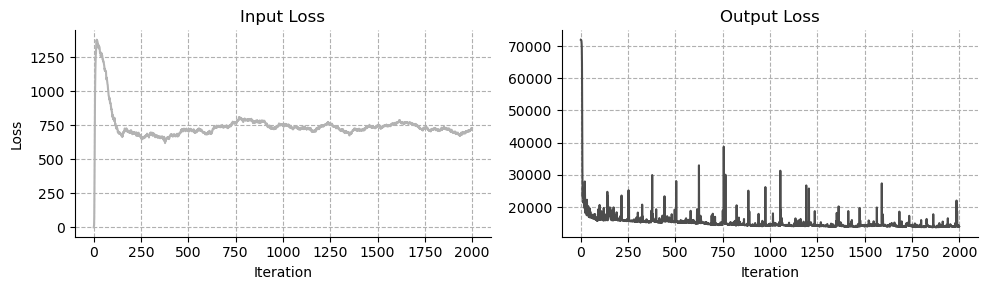

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(history['input_loss'],  c='0.7')
axes[0].set_title('Input Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--')

axes[1].plot(history['output_loss'], c='0.3')
axes[1].set_title('Output Loss')
axes[1].set_xlabel('Iteration')
axes[1].grid(True, linestyle='--')

sns.despine()
plt.tight_layout()
plt.show()

## 8. Number of Edits

In [11]:
n_edits = (torch.argmax(full_generated_seq, dim=1) != torch.argmax(X, dim=1)).sum().item()
print(f"Number of edited nucleotides: {n_edits:,}")

Number of edited nucleotides: 671


## 9. Predicted Contact Maps

In [12]:
model.eval()
with torch.no_grad():
    pred_optimised = model(full_generated_seq)
    pred_initial   = model(X)

r_opt, _ = pearsonr(
    pred_optimised.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
r_init, _ = pearsonr(
    pred_initial.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
print(f"Pearson R (optimised vs target) : {r_opt:.4f}")
print(f"Pearson R (initial   vs target) : {r_init:.4f}")

Pearson R (optimised vs target) : 0.7172
Pearson R (initial   vs target) : 0.9973


## 10. Contact Map Visualisation

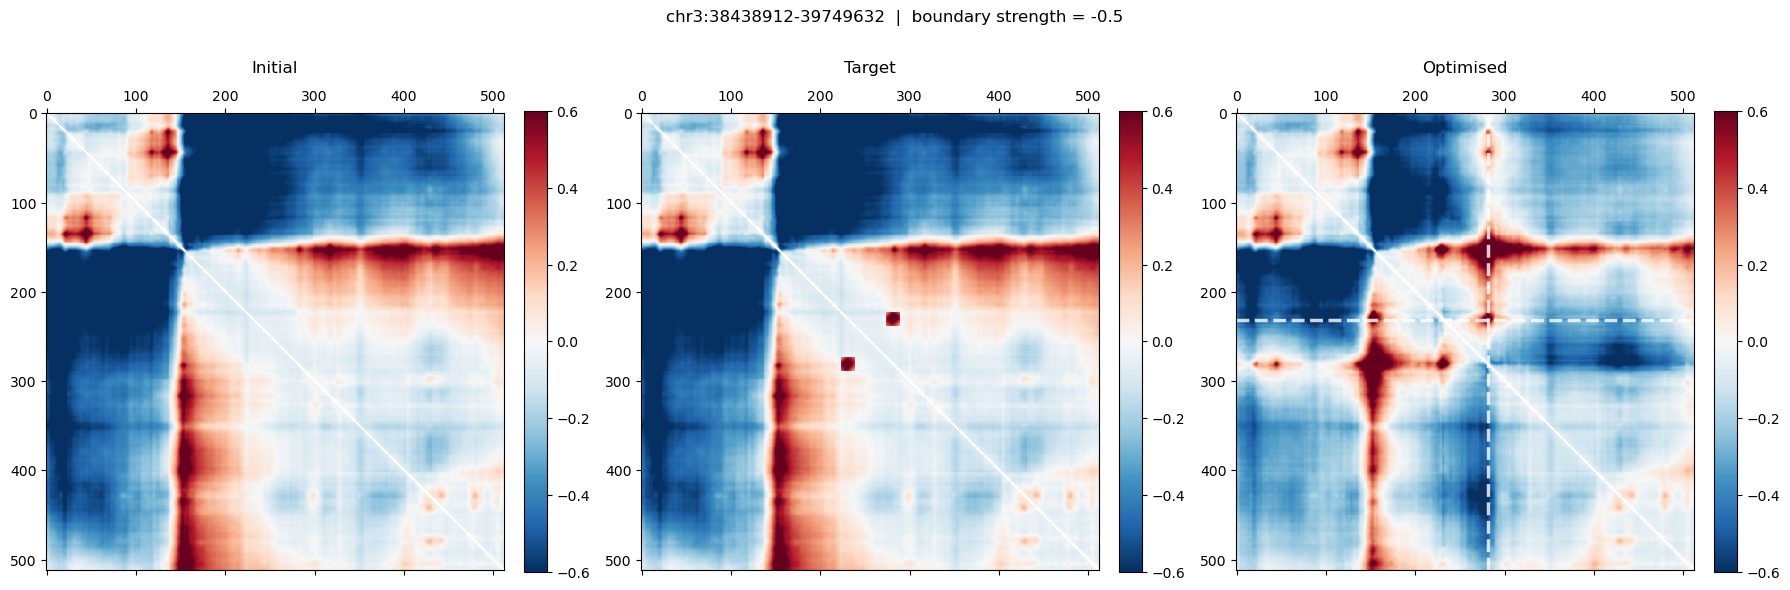

In [13]:
mat_initial   = from_upper_triu(pred_initial[0, 0, :],   matrix_len=512, num_diags=2)
mat_optimised = from_upper_triu(pred_optimised[0, 0, :],  matrix_len=512, num_diags=2)
mat_target    = from_upper_triu(target[0, 0, :],          matrix_len=512, num_diags=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Initial', 'Target', 'Optimised']
matrices = [mat_initial, mat_target, mat_optimised]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.matshow(mat.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_title(title, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# --- Add dashed lines to the 'Optimised' map ---
axes[2].axhline(y=231, color='white', linestyle='--', linewidth=2.5, alpha=0.8)
axes[2].axvline(x=281, color='white', linestyle='--', linewidth=2.5, alpha=0.8)

plt.suptitle(f"{CHROM}:{START}-{END}  |  boundary strength = -0.5", y=1.02)
plt.tight_layout()
# plt.savefig(f"./../plots/dot_sf_{STEM}.svg", format='svg', bbox_inches='tight')
plt.show()